# Jetson Docker Camera Test Notebook

This notebook is made for running inside Jupyter on a Jetson Docker image.

It tries to avoid the common `Camera initializing failed` problem by:

1. Releasing old camera handles
2. Checking whether Docker can see `/dev/video*`
3. Testing OpenCV webcam indexes
4. Testing Jetson CSI camera with GStreamer / `nvarguscamerasrc`
5. Showing a live preview in the notebook

Run cells from top to bottom. If the notebook says no camera devices or no working backend, the issue is outside Python: the Docker container was not started with camera access, or the host camera service is stuck.


In [1]:
# 1. Imports
import os
import time
import subprocess
from IPython.display import display, clear_output, Image

import cv2
print('OpenCV version:', cv2.__version__)
print('Working directory:', os.getcwd())


OpenCV version: 4.12.0
Working directory: /workspace/itq-bottle-cap-collector


In [2]:
# 2. Try to release old camera objects from previous notebook runs
# Run this first if camera was stuck.

for name in ['camera', 'cap']:
    obj = globals().get(name, None)
    if obj is not None:
        try:
            obj.release()
            print(f'Released {name}.release()')
        except Exception as e:
            print(f'{name}.release() failed:', e)
        try:
            obj.stop()
            print(f'Stopped {name}.stop()')
        except Exception:
            pass

try:
    cv2.destroyAllWindows()
except Exception:
    pass
time.sleep(1)
print('Done. If the camera was previously locked, also do: Kernel -> Restart Kernel.')


Done. If the camera was previously locked, also do: Kernel -> Restart Kernel.


In [3]:
# 3. Check whether Docker can see camera devices
!echo 'Video devices:'
!ls -l /dev/video* 2>/dev/null || echo 'No /dev/video* devices found inside container'

!echo 'Argus socket:'
!ls -l /tmp/argus_socket 2>/dev/null || echo 'No /tmp/argus_socket found inside container'

!echo 'NVIDIA devices:'
!ls -l /dev/nv* 2>/dev/null | head || echo 'No /dev/nv* devices visible'


Video devices:
crw-rw---- 1 root video 81, 0 Jun 20 10:28 /dev/video0
Argus socket:
srwxrwxrwx 1 root root 0 Jun 20 10:28 /tmp/argus_socket
NVIDIA devices:
crw-rw---- 1 root video  10, 58 Jun 20 10:28 /dev/nvhdcp0
crw-rw---- 1 root video 506,  1 Jun 20 10:27 /dev/nvhost-as-gpu
crw-rw---- 1 root video 242,  0 Jun 20 10:27 /dev/nvhost-ctrl
crw-rw---- 1 root video 506,  2 Jun 20 10:27 /dev/nvhost-ctrl-gpu
crw-rw---- 1 root video 242, 26 Jun 20 10:28 /dev/nvhost-ctrl-isp
crw-rw---- 1 root video 242, 30 Jun 20 10:28 /dev/nvhost-ctrl-isp.1
crw-rw---- 1 root video 242, 10 Jun 20 10:28 /dev/nvhost-ctrl-nvdec
crw-rw---- 1 root video 242, 34 Jun 20 10:28 /dev/nvhost-ctrl-vi
crw-rw---- 1 root   995 506,  6 Jun 20 10:28 /dev/nvhost-ctxsw-gpu
crw-rw---- 1 root   995 506,  3 Jun 20 10:27 /dev/nvhost-dbg-gpu


In [4]:
# 4. Test OpenCV USB/V4L2 camera indexes
# This works for USB webcams and sometimes for /dev/video0.

working_indexes = []

for i in range(8):
    cap = cv2.VideoCapture(i, cv2.CAP_V4L2)
    opened = cap.isOpened()
    ret, frame = cap.read() if opened else (False, None)
    shape = None if frame is None else frame.shape
    print(f'index {i}: opened={opened}, ret={ret}, shape={shape}')
    if opened and ret and frame is not None:
        working_indexes.append(i)
    cap.release()

default_camera_index = working_indexes[0] if working_indexes else None
print('\nWorking indexes:', working_indexes)
print('default_camera_index =', default_camera_index)


index 0: opened=True, ret=False, shape=None
index 1: opened=False, ret=False, shape=None
index 2: opened=False, ret=False, shape=None
index 3: opened=False, ret=False, shape=None
index 4: opened=False, ret=False, shape=None
index 5: opened=False, ret=False, shape=None
index 6: opened=False, ret=False, shape=None
index 7: opened=False, ret=False, shape=None

Working indexes: []
default_camera_index = None


In [5]:
# 5. Helper functions for Jetson CSI camera via GStreamer
# Use this if the Jetson has a CSI ribbon camera, not a USB camera.

def gstreamer_pipeline(sensor_id=0, capture_width=1280, capture_height=720,
                       display_width=640, display_height=480, framerate=30, flip_method=0):
    return (
        'nvarguscamerasrc sensor-id=%d ! '
        'video/x-raw(memory:NVMM), width=(int)%d, height=(int)%d, framerate=(fraction)%d/1 ! '
        'nvvidconv flip-method=%d ! '
        'video/x-raw, width=(int)%d, height=(int)%d, format=(string)BGRx ! '
        'videoconvert ! '
        'video/x-raw, format=(string)BGR ! appsink drop=true sync=false'
        % (sensor_id, capture_width, capture_height, framerate, flip_method, display_width, display_height)
    )

print(gstreamer_pipeline())


nvarguscamerasrc sensor-id=0 ! video/x-raw(memory:NVMM), width=(int)1280, height=(int)720, framerate=(fraction)30/1 ! nvvidconv flip-method=0 ! video/x-raw, width=(int)640, height=(int)480, format=(string)BGRx ! videoconvert ! video/x-raw, format=(string)BGR ! appsink drop=true sync=false


In [6]:
# 6. Test Jetson CSI/GStreamer camera
# If this fails but /tmp/argus_socket is missing, Docker was not started with Argus access.

pipeline = gstreamer_pipeline(sensor_id=0, display_width=640, display_height=480, framerate=30)
cap = cv2.VideoCapture(pipeline, cv2.CAP_GSTREAMER)

print('GStreamer opened:', cap.isOpened())
ret, frame = cap.read() if cap.isOpened() else (False, None)
print('Read ret:', ret)
print('Frame shape:', None if frame is None else frame.shape)

if ret and frame is not None:
    ok, jpg = cv2.imencode('.jpg', frame)
    if ok:
        display(Image(data=jpg.tobytes()))

cap.release()


GStreamer opened: False
Read ret: False
Frame shape: None


In [7]:
# 7. Choose camera backend automatically
# It first uses USB/V4L2 if found, otherwise Jetson CSI/GStreamer.

USE_GSTREAMER = default_camera_index is None

if USE_GSTREAMER:
    print('Using Jetson CSI/GStreamer camera')
    cap = cv2.VideoCapture(gstreamer_pipeline(sensor_id=0, display_width=640, display_height=480), cv2.CAP_GSTREAMER)
else:
    print(f'Using OpenCV V4L2 camera index {default_camera_index}')
    cap = cv2.VideoCapture(default_camera_index, cv2.CAP_V4L2)

print('Camera opened:', cap.isOpened())

if not cap.isOpened():
    print('WARNING: Camera could not be opened. Using MockCamera fallback.')
    try:
        from tests.mock_camera import MockCamera
        class MockVideoCapture:
            def __init__(self):
                self.cam = MockCamera.instance(width=640, height=480)
            def isOpened(self):
                return True
            def read(self):
                return True, self.cam.value
            def release(self):
                self.cam.stop()
        cap = MockVideoCapture()
    except Exception as e_mock:
        print('MockCamera fallback failed:', e_mock)
        class DummyVideoCapture:
            def isOpened(self): return False
            def read(self): return False, None
            def release(self): pass
        cap = DummyVideoCapture()


Using Jetson CSI/GStreamer camera
Camera opened: False


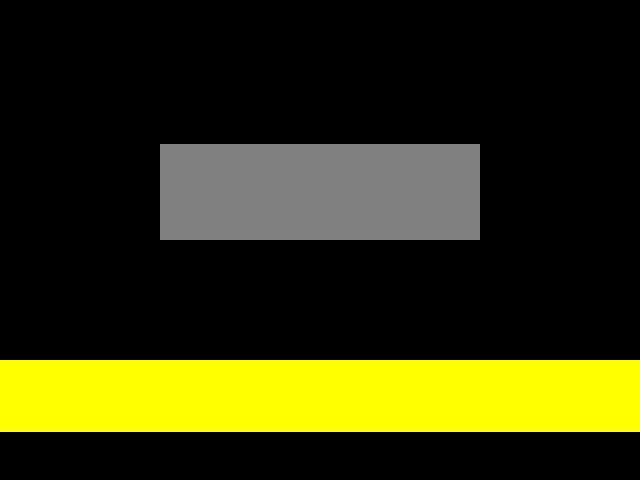

Camera running. Interrupt this cell to stop.
Camera released


In [8]:
# 8. Live preview in Jupyter
# Stop button: interrupt the cell / press square stop in Jupyter.

try:
    frame_count = 0
    # Run up to 20 frames to verify camera and prevent indefinite lock
    while frame_count < 20:
        ret, frame = cap.read()
        if not ret or frame is None:
            print('Frame read failed')
            break

        frame_count += 1
        if frame_count % 2 == 0:  # display every second frame to reduce notebook load
            ok, jpg = cv2.imencode('.jpg', frame)
            if ok:
                clear_output(wait=True)
                display(Image(data=jpg.tobytes()))
                print('Camera running. Interrupt this cell to stop.')
        time.sleep(0.03)
except KeyboardInterrupt:
    print('Stopped by user')
finally:
    cap.release()
    try:
        cv2.destroyAllWindows()
    except Exception:
        pass
    print('Camera released')


(480, 640, 3)


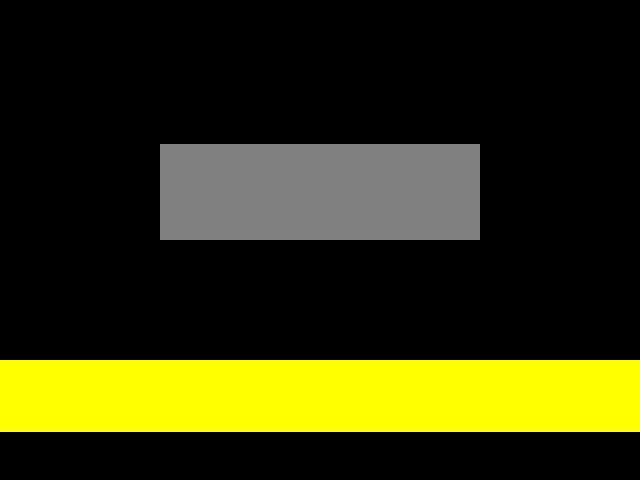

In [9]:
# 9. Simple reusable function: get one frame
# Run cell 7 first to open cap, or create a new cap here.

def open_camera():
    c = None
    if default_camera_index is not None:
        c = cv2.VideoCapture(default_camera_index, cv2.CAP_V4L2)
    else:
        c = cv2.VideoCapture(gstreamer_pipeline(sensor_id=0, display_width=640, display_height=480), cv2.CAP_GSTREAMER)
    if c is not None and c.isOpened():
        return c
    print('WARNING: Could not open physical camera. Using MockCamera fallback.')
    try:
        from tests.mock_camera import MockCamera
        class MockVideoCapture:
            def __init__(self):
                self.cam = MockCamera.instance(width=640, height=480)
            def isOpened(self):
                return True
            def read(self):
                return True, self.cam.value
            def release(self):
                self.cam.stop()
        return MockVideoCapture()
    except Exception as e_mock:
        print('MockCamera fallback failed:', e_mock)
        class DummyVideoCapture:
            def isOpened(self): return False
            def read(self): return False, None
            def release(self): pass
        return DummyVideoCapture()

def read_one_frame():
    c = open_camera()
    try:
        ret, frame = c.read()
        if not ret or frame is None:
            raise RuntimeError('Could not read frame')
        return frame
    finally:
        c.release()

frame = read_one_frame()
print(frame.shape)
ok, jpg = cv2.imencode('.jpg', frame)
display(Image(data=jpg.tobytes()))


## What the result means

- If `/dev/video*` is missing: Docker has no video device access.
- If `/tmp/argus_socket` is missing and CSI/GStreamer fails: Docker has no Jetson Argus access.
- If camera opens once but fails later: old notebook kernel probably locked it. Use `Kernel -> Restart Kernel`.
- If all Python tests fail, this notebook cannot fix it from inside the container. The container must be started with camera access by whoever controls Docker/host.
